<font style="color: red; font-size: 20px;">版本说明</font>  
<font style="color: red; font-size: 18px;">v2</font>
- 不使用分离的group1和group2数据重组数据，直接使用原始数据，清洗后做分析。减少逻辑复杂性。
- 使用原始数据的“synthetic_id”列做为被试人标志，而v1中使用新建的“participant”列

<font style="color: red; font-size: 18px;">v2.0a</font>
- 数据源使用"Z:/李玲珑_data/玲珑 at UCSD/20260306/20260402/dv_test_category_dataset.xlsx"文件，这是PC根据两个RA的分类做的修正版
- **注意：只运行到GLMM统计检验结果解读cell，后续内容没有更新**

# 分析思路说明

基于分类值1和3在每行出现的次数（分子），以及按该行 非 NaN 数据总量（分母） 计算得到的每个被试人的分类频率值分布。
然后用统计检验的方法检查两组答案分布存在显著差异

# 数据预处理

## 读取数据&查看数据基本信息

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# 文件路径
file_path = r"Z:/李玲珑_data/玲珑 at UCSD/20260306/20260402/dv_test_category_dataset.xlsx"

# 读取 Sheet 1
df = pd.read_excel(file_path, sheet_name="Sheet 1")

# 查看数据基本信息
print("数据形状:", df.shape)
# print("\n前5行数据:")
# print(df.head())
print("\n数据类型:")
print(df.dtypes)

# 保留 synthetic_id 列和 category_1 到 category_40 的列
category_cols = [f'category_{i}' for i in range(1, 41)]  # 生成 category_1 到 category_40 的列表
selected_cols = ['synthetic_id'] + category_cols
df = df[selected_cols]

df.head()

数据形状: (327, 81)

数据类型:
synthetic_id                int64
high_power_ideas#1_1_1        str
category_1                float64
high_power_ideas#1_2_1        str
category_2                float64
                           ...   
category_38               float64
low_power_ideas#1_19_1    float64
category_39               float64
low_power_ideas#1_20_1    float64
category_40               float64
Length: 81, dtype: object


,synthetic_id,category_1,category_2,category_3,category_4,category_5,category_6,category_7,category_8,category_9,...,category_31,category_32,category_33,category_34,category_35,category_36,category_37,category_38,category_39,category_40
0,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8,1.0,1.0,3.0,1.0,1.0,2.0,1.0,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 统计两组数据的各类别分布

In [4]:
# 分离两组数据
group1 = df.iloc[:, 1:21]  # category_1 到 category_20
group2 = df.iloc[:, 21:41]  # category_21 到 category_40

print("第一组 (category_1-20):")
print(f"列数: {group1.shape[1]}")
print(f"非空值数量: {group1.notna().sum().sum()}")
print(f"类别分布:\n{group1.stack().value_counts().sort_index()}")

print("\n" + "="*50)
print("第二组 (category_21-40):")
print(f"列数: {group2.shape[1]}")
print(f"非空值数量: {group2.notna().sum().sum()}")
print(f"类别分布:\n{group2.stack().value_counts().sort_index()}")


第一组 (category_1-20):
列数: 20
非空值数量: 538
类别分布:
1.0    365
2.0     37
3.0    128
4.0      8
Name: count, dtype: int64

第二组 (category_21-40):
列数: 20
非空值数量: 549
类别分布:
1.0    361
2.0     44
3.0    122
4.0     22
Name: count, dtype: int64


## 清洗数据
一般都建议清除空数据行，以便后续数据分析

In [5]:
# 保存原始数据
df_orginal = df.copy()

## --- 第一步：用NaN代替指定列（category_1 ~ category_40）中不是 1.0, 2.0, 3.0 的数据

# 1. 生成指定的列名列表 (category_1 到 category_40)
cols = [f'category_{i}' for i in range(1, 41)]

# 2. 定义允许保留的值
valid_values = [1.0, 2.0, 3.0]

# 3. 执行替换
# df[cols].isin(valid_values) 返回 True (如果是 1,2,3) 或 False
# ~ 取反，变成 True (如果不是 1,2,3)
# 将这些位置赋值为 np.nan
mask = ~df[cols].isin([1.0, 2.0, 3.0])
df.loc[:, cols] = df[cols].mask(mask, np.nan)
                      
# --- 第二步：删除指定的 category_1 ~ category_40 列中全为 NaN 的行 ---

print("删除空数据行之前的数据形状:", df.shape)

# subset=cols   只检查 category_1 ~ category_40
cols = [f"category_{i}" for i in range(1, 41)]
# how="all"     当这40列全部是 NaN 时才删除该行
df = df.dropna(subset=cols, how="all") 

print("删除空数据行之后的数据形状:", df.shape)

删除空数据行之前的数据形状: (327, 41)
删除空数据行之后的数据形状: (317, 41)


## 数据分组
为dataframe增加一个数据列 group，赋值逻辑如下：  
* 如果某行的category_1~category_20列中的值不全是NaN，则该行的group列值为group1,
* 如果某行的category_21~category_40列中的值不全是NaN，则该行的group列值为group2,
* 如果某行的category_1~category_20列 和 category_21~category_40列中的值都不全是NaN，则该行的group列值为error

### 逻辑解释

**判断 group1 是否有数据**

```python
g1 = ~df[cols1].isna().all(axis=1)
```

含义：

| category_1~20 | g1    |
| ------------- | ----- |
| 全 NaN         | False |
| 至少一个不是 NaN    | True  |

---

**判断 group2 是否有数据**

```python
g2 = ~df[cols2].isna().all(axis=1)
```

---

**分组逻辑**

| g1    | g2    | group  |
| ----- | ----- | ------ |
| True  | False | group1 |
| False | True  | group2 |
| True  | True  | error  |
| False | False | NaN    |

---

In [6]:
# 建立两个列名列表
cols1 = [f"category_{i}" for i in range(1, 21)]
cols2 = [f"category_{i}" for i in range(21, 41)]

# 判断每组是否存在非 NaN
g1 = ~df[cols1].isna().all(axis=1)
g2 = ~df[cols2].isna().all(axis=1)

df["group"] = np.select(
    [
        g1 & ~g2,   # 只有 group1
        g2 & ~g1,   # 只有 group2
        g1 & g2     # 两边都有
    ],
    [
        "Group1",
        "Group2",
        "error"
    ],
    default="missing"   # 两边都没有，赋值字符串missing，避免 np.select 函数报错
)

df.loc[df["group"]=="missing", "group"] = np.nan  # 再将字符串missing转为 NaN 以便后续分析

print(f"有{df[df["group"]=="error"].shape[0]}行的数据group 列的值是 error。" )
print(f"有{df[df["group"]=="missing"].shape[0]}行的数据group 列的值是 missing。" )

有0行的数据group 列的值是 error。
有0行的数据group 列的值是 missing。


## 保存数据

In [71]:
df.to_csv('Z:/李玲珑_data/玲珑 at UCSD/20260306/grouped_df_v2.csv', index=False)

# chatgpt的方案

## 分项检验

### 数据处理

In [10]:
import pandas as pd
import numpy as np

from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf

# ==============================
# 1 加载数据
# ==============================

# df = pd.read_csv("Z:/李玲珑_data/玲珑 at UCSD/20260306/grouped_df_v2.csv.csv")


print("---Group sizes: ---")
print(df["group"].value_counts())

# ==============================
# 2 转换 long format
# ==============================

long = df.melt(
    id_vars=["synthetic_id", "group"],
    var_name="question",
    value_name="response"
)

long = long.dropna() # 如果不加参数，dropna() 会检查每一行。只要某一行里 任意一个列 存在空值，这一整行就会被删除。

print("\n ---Total valid responses:---")
print(long.shape[0])

print("\n ---head 5 line of dataframe long--- ")
print(long.head(5))

print("\n ---显示 synthetic_id 列值为 8 的行--- ")
print(long[long['synthetic_id'] == 8])

# ==============================
# 3 计算每人频率
# ==============================

# 这段代码对之前转换得到的长格式 DataFrame long进行统计，计算每个参与者在不同问题上各类回答选项的频率（百分比）.
freq = (
    long.groupby(["synthetic_id","group"])["response"]
    .value_counts(normalize=True)   # 统计每个参与者在每个组内各种回答（response 值）的出现次数，并将次数转为频率（百分比）
    .unstack(fill_value=0)          # 将上一步得到的、以不同回答（response 值）为索引的多级 Series 转换为一个 DataFrame。每一列对应一个独特的回答（response 值），填充该参与者在该回答上的频率。如果某个回答从未出现，则用 0 填充（fill_value=0）。
    .reset_index()
)

# 通过 .rename()方法，有选择地重命名了 freqDataFrame 中的两列
freq = freq.rename(columns={   
    1: "freq_1",
    3: "freq_3"
})

print("\nFrequency table head:")
print(freq.head())
print("\nFrequency table tail:")
print(freq.tail())

# ==============================
# 4 描述统计
# ==============================

desc = freq.groupby("group")[["freq_1","freq_3"]].describe()

print("\nDescriptive statistics")
print(desc)

---Group sizes: ---
group
Group1    164
Group2    153
Name: count, dtype: int64

 ---Total valid responses:---
1057

 ---head 5 line of dataframe long--- 
    synthetic_id   group    question  response
3              8  Group1  category_1       1.0
4              9  Group1  category_1       2.0
7             12  Group1  category_1       1.0
10            15  Group1  category_1       1.0
11            16  Group1  category_1       1.0

 ---显示 synthetic_id 列值为 8 的行--- 
      synthetic_id   group    question  response
3                8  Group1  category_1       1.0
320              8  Group1  category_2       1.0
637              8  Group1  category_3       3.0
954              8  Group1  category_4       1.0
1271             8  Group1  category_5       1.0
1588             8  Group1  category_6       2.0
1905             8  Group1  category_7       1.0
2222             8  Group1  category_8       3.0

Frequency table head:
response  synthetic_id   group    freq_1       2.0    freq_3
0   

### Mann–Whitney U test 

In [11]:
# ==============================
# 5 Mann–Whitney U test
# ==============================

g1_f1 = freq[freq.group=="Group1"]["freq_1"]
g2_f1 = freq[freq.group=="Group2"]["freq_1"]

g1_f3 = freq[freq.group=="Group1"]["freq_3"]
g2_f3 = freq[freq.group=="Group2"]["freq_3"]

u1, p1 = mannwhitneyu(g1_f1, g2_f1, alternative="two-sided")
u3, p3 = mannwhitneyu(g1_f3, g2_f3, alternative="two-sided")

print("\nMann-Whitney U test")
print("freq_1: U =", u1, "p =", p1)
print("freq_3: U =", u3, "p =", p3)


Mann-Whitney U test
freq_1: U = 12226.5 p = 0.6883692392572883
freq_3: U = 13285.0 p = 0.34099984685421336


### logistic regression

In [12]:
# ==============================
# 6 logistic regression
# ==============================

long["is1"] = (long["response"] == 1).astype(int)

model = smf.logit("is1 ~ group", data=long).fit()

print("\nLogistic regression result")
print(model.summary())

# Odds ratio
odds_ratio = np.exp(model.params)

print("\nOdds Ratio")
print(odds_ratio)

Optimization terminated successfully.
         Current function value: 0.621590
         Iterations 5

Logistic regression result
                           Logit Regression Results                           
Dep. Variable:                    is1   No. Observations:                 1057
Model:                          Logit   Df Residuals:                     1055
Method:                           MLE   Df Model:                            1
Date:                Sun, 05 Apr 2026   Pseudo R-squ.:               1.259e-05
Time:                        08:55:11   Log-Likelihood:                -657.02
converged:                       True   LL-Null:                       -657.03
Covariance Type:            nonrobust   LLR p-value:                    0.8977
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.7940      0.094      8.463      0.000       0.61

### 整体类别分布

In [13]:
# ==============================
# 7 整体类别分布
# ==============================

overall = long.groupby(["group","response"]).size().unstack(fill_value=0)

print("\nOverall category counts")
print(overall)

print("\nOverall category proportions")

prop = overall.div(overall.sum(axis=1), axis=0)

print(prop)


Overall category counts
response  1.0  2.0  3.0
group                  
Group1    365   37  128
Group2    361   44  122

Overall category proportions
response       1.0       2.0       3.0
group                                 
Group1    0.688679  0.069811  0.241509
Group2    0.685009  0.083491  0.231499


## 使用 Generalized Linear Mixed Model 分析

**这个模型对应的统计模型**

$$
\text{logit}(P(is1)) =
\beta_0 + \beta_1 \cdot group +
u_{participant}
$$

其中

```
u_participant ~ N(0, σ²)
```

也就是论文中常写的：

```
is1 ~ group + (1 | participant)
```

---

**输出结果如何解释**

关键是这一行：

```
group[T.Group2]
```

假设输出：

```
coef = -0.24
```

计算 **Odds Ratio**

```
exp(-0.24) = 0.79
```

解释：

```
Group2 选择1的概率 ≈ Group1 的 0.79 倍
```

In [14]:
# ==============================
# 8 GLMM (Generalized Linear Mixed Model)
# ==============================

from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

print("\nRunning GLMM (logistic mixed model)")

# 构建数据列保存 响应变量 
long["is1"] = (long["response"] == 1).astype(int)

# 将 synthetic_id 列转换为分类变量
long["synthetic_id"] = long["synthetic_id"].astype("category")

# GLMM模型
model = BinomialBayesMixedGLM.from_formula(
    "is1 ~ group",
    {"synthetic_id": "0 + C(synthetic_id)"},
    long
)

result = model.fit_vb()

print("\nGLMM result")
print(result.summary())

# Odds ratio
# odds_ratio = np.exp(result.params)

print("\nGLMM Odds Ratios")
# print(odds_ratio)

fe = result.params[:2]

print("fixed effects: ", fe)
print("Odds ratios (fixed effects)")
print(np.exp(fe))


Running GLMM (logistic mixed model)

GLMM result
                  Binomial Mixed GLM Results
                Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
--------------------------------------------------------------
Intercept          M     0.8488   0.0692                      
group[T.Group2]    M     0.0117   0.0981                      
synthetic_id       V    -0.3485   0.0397 0.706   0.652   0.764
Parameter types are mean structure (M) and variance structure
(V)
Variance parameters are modeled as log standard deviations

GLMM Odds Ratios
fixed effects:  [0.84881847 0.0116783 ]
Odds ratios (fixed effects)
[2.33688412 1.01174676]


In [17]:
import numpy as np
print("固定效应 -> group[T.Group2] -> Odds Ratio:" , np.exp(0.0117))

print("Intercept -> baseline 概率:" , np.exp(0.8488)/(1 + np.exp(0.8488)))

print("随机效应 -> synthetic_id  -> participant SD:" , np.exp(-0.3485))

固定效应 -> group[T.Group2] -> Odds Ratio: 1.011768712718117
Intercept -> baseline 概率: 0.7003153545180867
随机效应 -> synthetic_id  -> participant SD: 0.7057459150239282



**一、GLMM模型结果解读**

你得到的核心输出是：

```
Binomial Mixed GLM Results
==============================================================
                Type Post. Mean Post. SD
--------------------------------------------------------------
Intercept          M     0.8488   0.0692                      
group[T.Group2]    M     0.0117   0.0981                      
synthetic_id       V    -0.3485   0.0397 0.706   0.652   0.764
==============================================================
```

模型：

$$
\text{logit}(P(\text{response}=1)) = \beta_0 + \beta_1 \cdot group + u_{participant}
$$

其中

```
u_participant ~ N(0, σ²)
```

---

**二、固定效应（最重要）**

group[T.Group2]

```
coef = 0.0117
```

含义：

```
Group2 相对于 Group1 的 log-odds 变化
```

计算 **Odds Ratio**

$$
OR = e^{0.0117}
$$

结果：

```
OR ≈ 1.0118
```

解释：

```
Group2 选择 1 的概率 ≈ Group1 的1.0118 倍
```

也就是说：

**Group2 极其轻微的倾向选择 1。**

---

**三、Intercept**

```
Intercept = 0.8488
```

对应的 baseline 概率：

$$
p = \frac{e^{0.8488}}{1+e^{0.8488}}
$$

结果：

```
p ≈ 0.7
```

解释：

```
Group1 选择 1 的平均概率 ≈ 70%
```

与你数据的整体比例非常接近。

---

**四、随机效应**

```
participant V = -0.3485
```

注意：

```
Variance parameters are modeled as log standard deviations
```

所以：

```math
SD = e^{-0.3485}
```

结果：

```
SD ≈ 0.706
```

解释：

```
不同 participant 之间存在较大差异
```

也就是：

```
个体差异明显
```

---


**五、统计结论**

综合 GLMM：

| 结果                  | 解释            |
| ------------------- | ------------- |
| Intercept OR=0.7   | Group1选择1概率较高 |
| Group2 OR=1.01      | Group2轻微多选择1   |
| participant SD≈0.706 | 个体差异明显        |

---

**六、结合之前所有统计**

完整结论：

| 分析                  | 结果         |
| ------------------- | ---------- |
| Mann-Whitney        | 不显著        |
| Logistic regression | Group2轻微多选1 |
| GLMM                | Group2轻微多选1 |

解释：

```
participant-level variation 较大
```

但：

```
总体回答层面基本不存在差异
```



#### GLMM统计检验

In [19]:
import numpy as np
from scipy.stats import norm

'''
# 响应变量
long["is1"] = (long["response"] == 1).astype(int)

# synthetic_id 转换为分类变量
long["synthetic_id"] = long["synthetic_id"].astype("category")

# GLMM模型
model = BinomialBayesMixedGLM.from_formula(
    "is1 ~ group",
    {"synthetic_id": "0 + C(synthetic_id)"},
    long
)

result = model.fit_vb()

print("\nGLMM result")
print(result.summary())
'''

# ==============================
# 固定效应
# ==============================

fe = result.fe_mean
se = result.fe_sd

names = result.model.exog_names


# ==============================
# 计算统计量
# ==============================

z = fe / se
p = 2 * (1 - norm.cdf(np.abs(z)))

ci_low = fe - 1.96 * se
ci_high = fe + 1.96 * se

# Odds ratio
or_val = np.exp(fe)
or_low = np.exp(ci_low)
or_high = np.exp(ci_high)


# ==============================
# 输出结果
# ==============================

print("\nGLMM fixed effects results\n")

for i in range(len(names)):

    print(names[i])
    print("beta =", fe[i])
    print("SE =", se[i])
    print("z =", z[i])
    print("p =", p[i])

    print("95% CI (log-odds) =", ci_low[i], ",", ci_high[i])

    print("Odds Ratio =", or_val[i])
    print("OR 95% CI =", or_low[i], ",", or_high[i])

    print()


GLMM fixed effects results

Intercept
beta = 0.8488184700883
SE = 0.06919441423605206
z = 12.26715305649692
p = 0.0
95% CI (log-odds) = 0.713197418185638 , 0.9844395219909621
Odds Ratio = 2.3368841216332656
OR 95% CI = 2.0405051876144613 , 2.6763114502669434

group[T.Group2]
beta = 0.011678300909340406
SE = 0.0981399015420619
z = 0.11899646041865233
p = 0.905278160033846
95% CI (log-odds) = -0.18067590611310091 , 0.20403250793178174
Odds Ratio = 1.0117467584952873
OR 95% CI = 0.8347058379225197 , 1.2263380185208892



In [20]:
print(names)
print(fe)
print(se)

['Intercept', 'group[T.Group2]']
[0.84881847 0.0116783 ]
[0.06919441 0.0981399 ]


#### GLMM统计检验结果解读


```python
z = fe / se
```

代码计算了：

```
z = beta / SE
```

这相当于 **Wald test**。

---

**Intercept 的统计检验**

```
beta = 0.580
SE = 0.0656
z = 8.85
p < 0.001
```

解释：

```
baseline probability 显著不为 0
```

但通常 **Intercept 的显著性不太重要**。

---

**group[T.Group2] 的统计检验**

```
beta = -0.3339
SE = 0.0905
z = -3.69
p = 0.000224
```

解释：

```
Group effect 显著
```

即：

> Group2 与 Group1 在 response=1 的概率上存在显著差异。

---

**group[T.Group2] 的95%置信区间**

log-odds CI：

```
-0.511 , -0.157
```

转成 OR：

```
0.600 , 0.855
```

解释：

```
Group2 odds 约为 Group1 odds 的 0.60–0.86 倍
```

因为区间 **不包含 1**：

```
差异显著
```

#### 检验随机效应是否服从正态分布
虽然 GLMM 要求随机效应服从正态分布，但是GLMM 对随机效应正态假设并不非常敏感  
即使真实分布略偏离正态： 
* 固定效应估计通常仍然稳定。

一个 GLMM 实践中非常关键但很多教材不讲的事实：**随机效应是否正态，其实大多数情况下并不会影响固定效应推断。**

In [112]:
# 查看result.random_effects()返回的数据结构
re = result.random_effects()

print(type(re))
print(np.shape(re))
print(re[:5])

<class 'pandas.DataFrame'>
(339, 2)
                        Mean        SD
C(synthetic_id)[1]  0.067354  0.738748
C(synthetic_id)[2] -0.354235  0.728893
C(synthetic_id)[3]  0.269557  0.845496
C(synthetic_id)[4]  0.182197  0.733192
C(synthetic_id)[5] -0.439732  0.837891


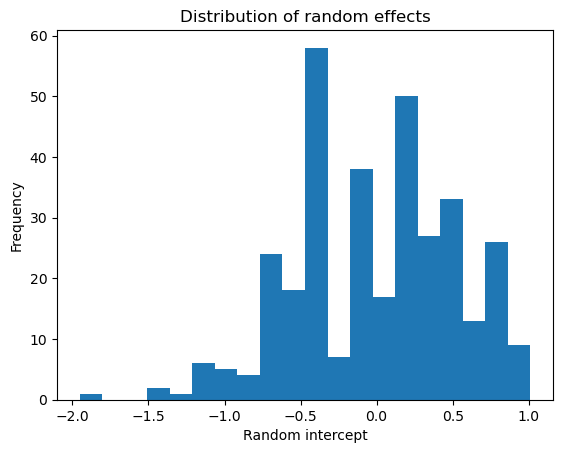

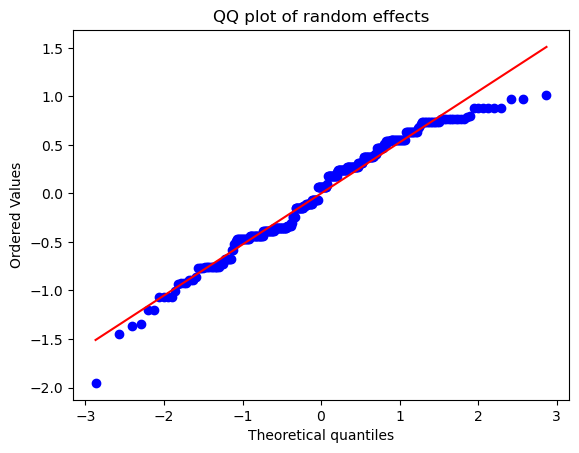

Shapiro-Wilk p = 5.397676724009005e-06
     p值  --- 结论
p > 0.05  --- 不拒绝正态
p < 0.05  --- 偏离正态


In [113]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# 提取随机效应,得到每个 synthetic_id 的随机截距。
re_df = result.random_effects()
re_vals = re_df["Mean"].values

# 画直方图
plt.hist(re_vals, bins=20)
plt.title("Distribution of random effects")
plt.xlabel("Random intercept")
plt.ylabel("Frequency")
plt.show()

# QQ plot
stats.probplot(re_vals, dist="norm", plot=plt)
plt.title("QQ plot of random effects")
plt.show()

# Shapiro-Wilk 正态检验（可选）
from scipy.stats import shapiro

stat, p = shapiro(re_vals)

print("Shapiro-Wilk p =", p)

print("     p值  --- 结论")
print("p > 0.05  --- 不拒绝正态")
print("p < 0.05  --- 偏离正态")


#### Caterpillar Plot（GLMM经典图）
如果图形左右对称围绕0，说明随机效应分布合理。

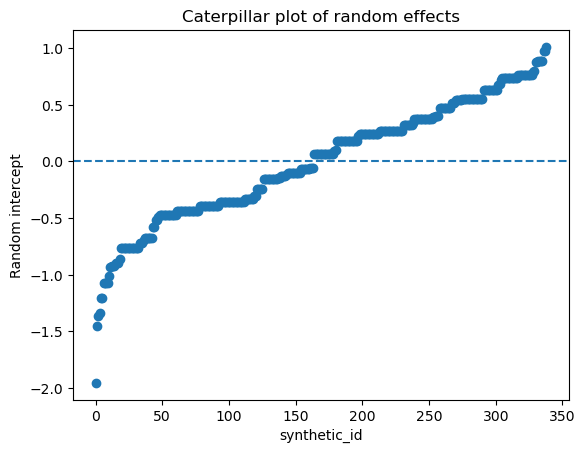

In [111]:
re_sorted = np.sort(re_vals)

plt.plot(re_sorted, "o")
plt.axhline(0, linestyle="--")
plt.title("Caterpillar plot of random effects")
plt.ylabel("Random intercept")
plt.xlabel("synthetic_id")
plt.show()

#### 如何解释随机效应数值

例如：

```
participant A: 0.27
```

表示：

如果平均 log-odds 是：

```
0.58
```

该 participant 的 baseline：

```
0.58 + 0.27 = 0.85
```

说明：

```text
这个 participant 更倾向于选择1
```

## 卡方检验

In [82]:
# ==============================
# 9 Chi-square test
# ==============================

from scipy.stats import chi2_contingency
import numpy as np

print("\nChi-square test (Group × Response)")

# 构造列联表
table = (
    long.groupby(["group", "response"])
    .size()
    .unstack(fill_value=0)
)

print("\nContingency table")
print(table)

# 卡方检验
chi2, p, dof, expected = chi2_contingency(table)

print("\nChi-square test result")
print("Chi2 =", chi2)
print("df =", dof)
print("p =", p)

# ==============================
# 计算 Cramer's V (效应量)
# ==============================

n = table.values.sum()

r, c = table.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))

print("\nEffect size (Cramer's V)")
print(cramers_v)

# ==============================
# 期望频数
# ==============================

print("\nExpected frequencies")
print(expected)


Chi-square test (Group × Response)

Contingency table
response  1.0  2.0  3.0
group                  
Group1    344   23  179
Group2    314   33  231

Chi-square test result
Chi2 = 8.844754273111574
df = 2
p = 0.012005659245701706

Effect size (Cramer's V)
0.08870737547477323

Expected frequencies
[[319.63345196  27.20284698 199.16370107]
 [338.36654804  28.79715302 210.83629893]]


**结论**：
- p < 0.05，两组的回答分布存在显著差异 
- Cramer's V = 0.0887，差异显著但效应较小 

### stacked bar plot

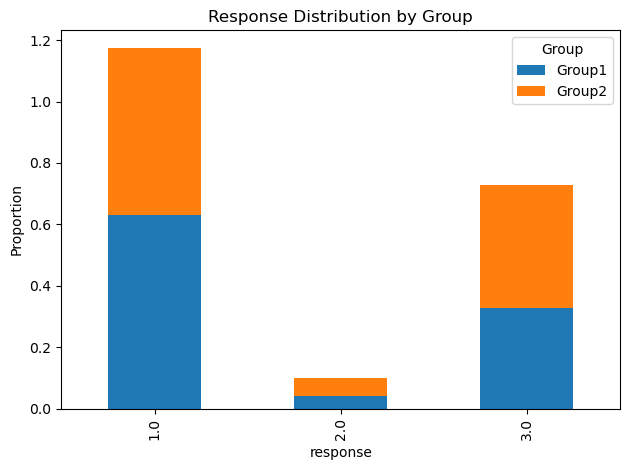

In [83]:
import matplotlib.pyplot as plt

prop = table.div(table.sum(axis=1), axis=0)

prop.T.plot(kind="bar", stacked=True)

plt.ylabel("Proportion")
plt.title("Response Distribution by Group")

plt.legend(title="Group")

plt.tight_layout()

plt.show()

## all-in-one